# KKBOX Churn Prediction — Preprocessing Pipeline

This notebook covers the full preprocessing pipeline for the KKBOX Music Streaming Service Churn Prediction challenge.

The goal is to transform raw data from three sources (train labels, member demographics, and transaction history) into a clean, model-ready feature matrix.

**Pipeline Overview:**
1. Load raw data
2. Clean member demographics
3. Clean transaction data
4. Engineer transaction-level features
5. Merge all data sources
6. Encode categorical features
7. Handle remaining missing values
8. Final dataset inspection

## Step 0 — Import Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)  # show all columns when printing DataFrames
pd.set_option('display.float_format', '{:.4f}'.format)  # cleaner float display

## Step 1 — Load Raw Data

We load three datasets:
- **train_v2.csv** — the target labels: one row per user with `msno` (user ID) and `is_churn` (0 or 1)
- **members_v3.csv** — user demographic information: age, gender, city, registration method and date
- **transactions_v2.csv** — full transaction history: payment amounts, plan duration, cancellation flags, expiry dates

These three tables are linked by the `msno` key (hashed user ID).

In [15]:
train = pd.read_csv("../data/train_v2.csv")
members = pd.read_csv("../data/members_v3.csv")
transactions = pd.read_csv("../data/transactions_v2.csv")

print(f"Train shape      : {train.shape}")
print(f"Members shape    : {members.shape}")
print(f"Transactions shape: {transactions.shape}")

print("\n--- Train sample ---")
display(train.head(3))

print("\n--- Members sample ---")
display(members.head(3))

print("\n--- Transactions sample ---")
display(transactions.head(3))

Train shape      : (970960, 2)
Members shape    : (6769473, 6)
Transactions shape: (1431009, 9)

--- Train sample ---


,msno,is_churn
0,ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=,1
1,f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=,1
2,zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=,1



--- Members sample ---


,msno,city,bd,gender,registered_via,registration_init_time
0,Rb9UwLQTrxzBVwCB6+bCcSQWZ9JiNLC9dXtM1oEsZA8=,1,0,NaN,11,20110911
1,+tJonkh+O1CA796Fm5X60UMOtB6POHAwPjbTRVl/EuU=,1,0,NaN,7,20110914
2,cV358ssn7a0f7jZOwGNWS07wCKVqxyiImJUX6xcIwKw=,1,0,NaN,11,20110915



--- Transactions sample ---


,msno,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,transaction_date,membership_expire_date,is_cancel
0,++6eU4LsQ3UQ20ILS7d99XK8WbiVgbyYL4FUgzZR134=,32,90,298,298,0,20170131,20170504,0
1,++lvGPJOinuin/8esghpnqdljm6NXS8m8Zwchc7gOeA=,41,30,149,149,1,20150809,20190412,0
2,+/GXNtXWQVfKrEDqYAzcSw2xSPYMKWNj22m+5XkVQZc=,36,30,180,180,1,20170303,20170422,0


## Step 2 — Clean Member Demographics

The `members` table has two known data quality issues:

### 2a. Age (`bd`) — Outlier Clipping
The `bd` column (birth date / age) contains extreme outlier values ranging from **-7168 to 2016**, which are clearly data entry errors. We clip the values to a realistic range of **10 to 80** years old.

- Values below 10 or above 80 are replaced with 10 or 80 respectively.
- This preserves the distribution of valid ages while removing noise.

### 2b. Gender — Missing Value Imputation
The `gender` column has a large number of missing values (~57% of members). Rather than dropping these rows or imputing with male/female, we fill them with the string `'unknown'` to preserve the information that gender was not provided — this can itself be a signal for churn.

In [3]:
print("=== Before Cleaning ===")
print(f"Age (bd) range   : {members['bd'].min()} to {members['bd'].max()}")
print(f"Gender nulls     : {members['gender'].isnull().sum()} ({members['gender'].isnull().mean()*100:.1f}%)")

=== Before Cleaning ===
Age (bd) range   : -7168 to 2016
Gender nulls     : 4429505 (65.4%)


In [4]:
# --- 2a. Clip age to realistic range [10, 80] ---
# clip(lower, upper) replaces values outside the range with the boundary value
members['bd'] = members['bd'].clip(10, 80)

# --- 2b. Fill missing gender with 'unknown' ---
# fillna replaces NaN with the given value
members['gender'] = members['gender'].fillna('unknown')

print("=== After Cleaning ===")
print(f"Age (bd) range   : {members['bd'].min()} to {members['bd'].max()}")
print(f"Gender nulls     : {members['gender'].isnull().sum()}")
print(f"Gender distribution:")
print(members['gender'].value_counts())

=== After Cleaning ===
Age (bd) range   : 10 to 80
Gender nulls     : 0
Gender distribution:
gender
unknown    4429505
male       1195355
female     1144613
Name: count, dtype: int64


## Step 3 — Clean Transaction Data

The `transactions` table requires three cleaning steps:

### 3a. Remove Duplicate Rows
Duplicate transaction records can skew aggregated features (e.g., inflating total payment amounts). We drop exact duplicates.

### 3b. Clip Payment Amount
The `actual_amount_paid` column contains some extreme values. We clip it to **[0, 5000]** to remove likely data errors while keeping valid high-value plans.

### 3c. Convert Date Columns to Datetime
Both `transaction_date` and `membership_expire_date` are stored as integers in `YYYYMMDD` format (e.g., `20170331`). We convert them to proper `datetime` objects so we can compute date differences and sort by time.

In [5]:
print(f"Rows before dedup: {len(transactions)}")

# --- 3a. Drop duplicate rows ---
transactions = transactions.drop_duplicates()
print(f"Rows after dedup : {len(transactions)}")

# --- 3b. Clip payment amount to [0, 5000] ---
# Negative payments and extremely large values are likely errors
transactions['actual_amount_paid'] = transactions['actual_amount_paid'].clip(0, 5000)

# --- 3c. Convert integer dates (YYYYMMDD) to datetime ---
# astype(str) converts 20170331 → '20170331', then pd.to_datetime parses it
transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date'].astype(str), format='%Y%m%d', errors='coerce'
)
transactions['membership_expire_date'] = pd.to_datetime(
    transactions['membership_expire_date'].astype(str), format='%Y%m%d', errors='coerce'
)

print("\nDate columns after conversion:")
display(transactions[['transaction_date', 'membership_expire_date']].head())
print(f"\nPayment amount range: {transactions['actual_amount_paid'].min()} to {transactions['actual_amount_paid'].max()}")

Rows before dedup: 1431009
Rows after dedup : 1431009

Date columns after conversion:


,transaction_date,membership_expire_date
0,2017-01-31,2017-05-04
1,2015-08-09,2019-04-12
2,2017-03-03,2017-04-22
3,2017-03-29,2017-03-31
4,2017-03-23,2017-04-23



Payment amount range: 0 to 2000


## Step 4 — Engineer Transaction Features

The `transactions` table has **multiple rows per user** (one per transaction). We need to aggregate it down to **one row per user** before merging with the train labels.

We compute the following aggregated features per user:

| Feature | Description |
|---|---|
| `actual_amount_paid_mean` | Average payment per transaction |
| `actual_amount_paid_sum` | Total amount paid across all transactions |
| `payment_plan_days_mean` | Average subscription plan length (in days) |
| `is_cancel_sum` | Total number of cancellation events |
| `is_auto_renew_mean` | Proportion of transactions with auto-renew enabled |

We then derive two **ratio features**:
- `cancel_rate` — cancellations per day of subscription (higher = more likely to churn)
- `payment_per_day` — average daily spend (lower = less engaged user)

The `+1` in the denominator is a **Laplace smoothing** trick to avoid division by zero.

In [6]:
# --- Aggregate transactions to one row per user ---
# groupby('msno') groups all transactions belonging to the same user
# agg() applies multiple aggregation functions to multiple columns at once
trans_agg = transactions.groupby('msno').agg({
    'actual_amount_paid' : ['mean', 'sum'],   # average and total payment
    'payment_plan_days'  : ['mean'],           # average plan length
    'is_cancel'          : ['sum'],            # total cancellations
    'is_auto_renew'      : ['mean']            # auto-renew rate
})

# Flatten multi-level column names: ('actual_amount_paid', 'mean') → 'actual_amount_paid_mean'
trans_agg.columns = ['_'.join(col) for col in trans_agg.columns]
trans_agg = trans_agg.reset_index()

# --- Derive ratio features ---
# cancel_rate: how often does the user cancel relative to their plan length?
trans_agg['cancel_rate'] = (
    trans_agg['is_cancel_sum'] / (trans_agg['payment_plan_days_mean'] + 1)
)

# payment_per_day: how much does the user pay per day of subscription?
trans_agg['payment_per_day'] = (
    trans_agg['actual_amount_paid_sum'] / (trans_agg['payment_plan_days_mean'] + 1)
)

print(f"Transaction features shape: {trans_agg.shape}")
print(f"Columns: {list(trans_agg.columns)}")
display(trans_agg.head())

Transaction features shape: (1197050, 8)
Columns: ['msno', 'actual_amount_paid_mean', 'actual_amount_paid_sum', 'payment_plan_days_mean', 'is_cancel_sum', 'is_auto_renew_mean', 'cancel_rate', 'payment_per_day']


,msno,actual_amount_paid_mean,actual_amount_paid_sum,payment_plan_days_mean,is_cancel_sum,is_auto_renew_mean,cancel_rate,payment_per_day
0,+++IZseRRiQS9aaSkH6cMYU6bGDcxUieAi/tH67sC5s=,1599.0000,1599,395.0000,0,0.0000,0.0000,4.0379
1,+++hVY1rZox/33YtvDgmKA2Frg/2qhkz12B9ylCvh8o=,99.0000,99,30.0000,0,1.0000,0.0000,3.1935
2,+++l/EXNMLTijfLBa8p2TUVVVp2aFGSuUI/h7mLmthw=,149.0000,298,30.0000,0,1.0000,0.0000,9.6129
3,+++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=,149.0000,149,30.0000,0,1.0000,0.0000,4.8065
4,++/9R3sX37CjxbY/AaGvbwr3QkwElKBCtSvVzhCBDOk=,149.0000,149,30.0000,0,1.0000,0.0000,4.8065


## Step 5 — Engineer Temporal Features

Beyond aggregated payment behavior, **time-based features** are important signals for churn.

We take the **last transaction** per user (the one with the latest `membership_expire_date`) and compute:

- `days_left` — how many days remain on the membership as of the reference date `2017-03-01` (the snapshot date of the dataset). A user with many days left who still churns is a strong signal.
- `days_since_last_transaction` — how many days have passed since the user's last transaction. A user who hasn't transacted recently may be disengaging.

**Why take the last transaction?**  
Each user may have dozens of transactions. The most recent one best reflects their current subscription status.

In [7]:
REFERENCE_DATE = pd.to_datetime('2017-03-01')

# --- Get the last transaction per user (latest membership_expire_date) ---
# sort_values ensures the last row per group is the one with the latest expiry
last_trans = (
    transactions
    .sort_values('membership_expire_date')
    .groupby('msno')
    .tail(1)                          # keep only the last row per user
    [['msno', 'membership_expire_date', 'transaction_date']]  # keep only needed columns
)

# --- Compute days_left: days from reference date until membership expires ---
# Positive = membership still active, Negative = already expired
last_trans['days_left'] = (
    last_trans['membership_expire_date'] - REFERENCE_DATE
).dt.days

# --- Compute days_since_last_transaction: how long since the user last transacted ---
last_trans['days_since_last_transaction'] = (
    REFERENCE_DATE - last_trans['transaction_date']
).dt.days

# Keep only the engineered temporal features
temporal_feat = last_trans[['msno', 'days_left', 'days_since_last_transaction']]

print(f"Temporal features shape: {temporal_feat.shape}")
display(temporal_feat.describe())

Temporal features shape: (1197050, 3)


,days_left,days_since_last_transaction
count,1197050.0000,1197050.0000
mean,72.5453,7.3501
std,79.3827,75.4642
min,-315.0000,-30.0000
25%,40.0000,-24.0000
50%,50.0000,-13.0000
75%,60.0000,-3.0000
max,7168.0000,789.0000


## Step 6 — Merge All Data Sources

Now we combine all cleaned and engineered tables into a single DataFrame:

```
train  ──left join──>  members  ──left join──>  trans_agg  ──left join──>  temporal_feat
```

We use **left joins** throughout to keep all users from the `train` set. If a user has no matching record in another table, their features will be `NaN` (handled in Step 8).

In [8]:
# --- Merge train + members ---
df = train.merge(members, on='msno', how='left')
print(f"After merging members    : {df.shape}")

# --- Merge + transaction aggregated features ---
df = df.merge(trans_agg, on='msno', how='left')
print(f"After merging trans_agg  : {df.shape}")

# --- Merge + temporal features ---
df = df.merge(temporal_feat, on='msno', how='left')
print(f"After merging temporal   : {df.shape}")

print("\nFull column list:")
print(list(df.columns))

After merging members    : (970960, 7)
After merging trans_agg  : (970960, 14)
After merging temporal   : (970960, 16)

Full column list:
['msno', 'is_churn', 'city', 'bd', 'gender', 'registered_via', 'registration_init_time', 'actual_amount_paid_mean', 'actual_amount_paid_sum', 'payment_plan_days_mean', 'is_cancel_sum', 'is_auto_renew_mean', 'cancel_rate', 'payment_per_day', 'days_left', 'days_since_last_transaction']


## Step 7 — Encode Categorical Features

Machine learning models (like XGBoost) require numeric inputs. We need to convert categorical columns to numbers.

We use **One-Hot Encoding** (via `pd.get_dummies`) for:
- `city` — categorical city code (values 1–22, not ordinal)
- `gender` — `'male'`, `'female'`, `'unknown'`

**Why not label encoding?**  
Label encoding (e.g., city 1=1, city 2=2) implies an ordinal relationship that doesn't exist here. One-hot encoding creates a separate binary column for each category, avoiding this false ordering.

`dummy_na=True` creates an extra column for rows where the original value was `NaN`, preserving that information.

In [9]:
print(f"Shape before encoding: {df.shape}")
print(f"Unique cities: {df['city'].nunique()}")
print(f"Gender values: {df['gender'].unique()}")

# --- One-hot encode city and gender ---
# pd.get_dummies creates a new binary column for each unique value
# dummy_na=True also creates a column for NaN values
df = pd.get_dummies(df, columns=['city', 'gender'], dummy_na=True)

print(f"\nShape after encoding : {df.shape}")
# Show the new one-hot columns
new_cols = [c for c in df.columns if c.startswith('city_') or c.startswith('gender_')]
print(f"New encoded columns  : {new_cols}")

Shape before encoding: (970960, 16)
Unique cities: 21
Gender values: ['male' 'unknown' 'female' nan]

Shape after encoding : (970960, 40)
New encoded columns  : ['city_1.0', 'city_3.0', 'city_4.0', 'city_5.0', 'city_6.0', 'city_7.0', 'city_8.0', 'city_9.0', 'city_10.0', 'city_11.0', 'city_12.0', 'city_13.0', 'city_14.0', 'city_15.0', 'city_16.0', 'city_17.0', 'city_18.0', 'city_19.0', 'city_20.0', 'city_21.0', 'city_22.0', 'city_nan', 'gender_female', 'gender_male', 'gender_unknown', 'gender_nan']


## Step 8 — Handle Remaining Missing Values

After merging, some users may still have `NaN` values because:
- They have no matching record in `members` (no demographic info)
- They have no transaction history

We inspect the remaining nulls and fill them with `0`.

**Why fill with 0?**  
- For numeric aggregations (sum, mean), `0` is a reasonable default meaning "no activity"
- For one-hot encoded columns, `0` means "not in this category"
- For `days_left` and `days_since_last_transaction`, `0` is a neutral placeholder

This is a simple strategy. In production, more sophisticated imputation (e.g., median imputation, model-based) could be used.

In [10]:
# --- Inspect missing values before filling ---
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Columns with missing values:")
print(missing)

# --- Fill all remaining NaN with 0 ---
df = df.fillna(0)

print(f"\nTotal nulls after fillna: {df.isnull().sum().sum()}")

Columns with missing values:
bd                             109993
registered_via                 109993
registration_init_time         109993
actual_amount_paid_mean         37382
actual_amount_paid_sum          37382
payment_plan_days_mean          37382
is_cancel_sum                   37382
is_auto_renew_mean              37382
cancel_rate                     37382
payment_per_day                 37382
days_left                       37382
days_since_last_transaction     37382
dtype: int64

Total nulls after fillna: 0


## Step 9 — Final Dataset Inspection

Before passing the data to a model, we do a final sanity check:
- Confirm shape and column types
- Check the target variable distribution is preserved
- Preview the final feature matrix

In [11]:
print(f"Final dataset shape: {df.shape}")
print(f"Total features     : {df.shape[1] - 2} (excluding msno and is_churn)")
print(f"\nTarget distribution:")
print(df['is_churn'].value_counts(normalize=True).rename({0: 'not churn', 1: 'churn'}))

print("\nData types:")
print(df.dtypes.value_counts())

print("\nSample rows:")
display(df.drop(columns=['msno']).head())

Final dataset shape: (970960, 40)
Total features     : 38 (excluding msno and is_churn)

Target distribution:
is_churn
not churn   0.9101
churn       0.0899
Name: proportion, dtype: float64

Data types:
bool       26
float64    12
object      1
int64       1
Name: count, dtype: int64

Sample rows:


,is_churn,bd,registered_via,registration_init_time,actual_amount_paid_mean,actual_amount_paid_sum,payment_plan_days_mean,is_cancel_sum,is_auto_renew_mean,cancel_rate,payment_per_day,days_left,days_since_last_transaction,city_1.0,city_3.0,city_4.0,city_5.0,city_6.0,city_7.0,city_8.0,city_9.0,city_10.0,city_11.0,city_12.0,city_13.0,city_14.0,city_15.0,city_16.0,city_17.0,city_18.0,city_19.0,city_20.0,city_21.0,city_22.0,city_nan,gender_female,gender_male,gender_unknown,gender_nan
0,1,28.0000,3.0000,20131223.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
1,1,20.0000,3.0000,20131223.0000,180.0000,180.0000,30.0000,0.0000,0.0000,0.0000,5.8065,41.0000,-10.0000,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2,1,18.0000,3.0000,20131227.0000,150.0000,300.0000,75.0000,0.0000,0.0000,0.0000,3.9474,106.0000,-13.0000,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False
3,1,10.0000,7.0000,20140109.0000,149.0000,1490.0000,30.0000,0.0000,1.0000,0.0000,48.0645,313.0000,449.0000,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
4,1,35.0000,7.0000,20140125.0000,99.0000,792.0000,30.0000,1.0000,1.0000,0.0323,25.5484,201.0000,-15.0000,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False


In [12]:
# --- Summary statistics of key numeric features ---
key_features = [
    'bd', 'actual_amount_paid_mean', 'actual_amount_paid_sum',
    'payment_plan_days_mean', 'is_cancel_sum', 'is_auto_renew_mean',
    'cancel_rate', 'payment_per_day', 'days_left', 'days_since_last_transaction'
]

display(df[key_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
bd,970960.0000,16.8257,12.4963,0.0000,10.0000,10.0000,26.0000,80.0000
actual_amount_paid_mean,970960.0000,138.2269,134.0101,0.0000,99.0000,149.0000,149.0000,2000.0000
actual_amount_paid_sum,970960.0000,169.0824,229.8410,0.0000,99.0000,149.0000,149.0000,13650.0000
payment_plan_days_mean,970960.0000,32.3719,31.5971,0.0000,30.0000,30.0000,30.0000,450.0000
is_cancel_sum,970960.0000,0.0339,0.1844,0.0000,0.0000,0.0000,0.0000,8.0000
is_auto_renew_mean,970960.0000,0.8770,0.3274,0.0000,1.0000,1.0000,1.0000,1.0000
cancel_rate,970960.0000,0.0011,0.0059,0.0000,0.0000,0.0000,0.0000,0.1892
payment_per_day,970960.0000,4.9316,5.8232,0.0000,3.1935,4.8065,4.8065,440.3226
days_left,970960.0000,53.0426,49.8637,-1.0000,38.0000,48.0000,57.0000,2360.0000
days_since_last_transaction,970960.0000,-12.6331,39.4232,-30.0000,-25.0000,-16.0000,-7.0000,789.0000


## Step 10 — Feature Correlation with Churn

As a final check, we compute the **Pearson correlation** between each numeric feature and the target `is_churn`. This gives a quick view of which features are most linearly associated with churn.

Note: correlation only captures linear relationships. Tree-based models like XGBoost can capture non-linear patterns too, so a low correlation does not mean a feature is useless.

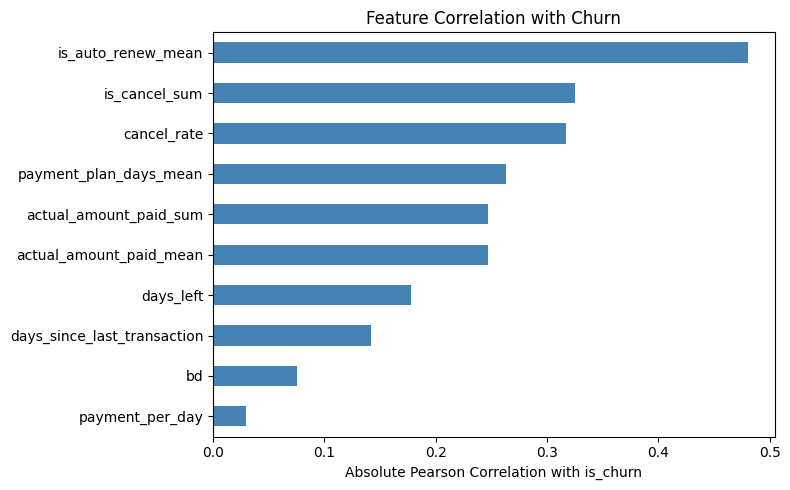

is_cancel_sum                  0.3247
cancel_rate                    0.3169
payment_plan_days_mean         0.2629
actual_amount_paid_sum         0.2470
actual_amount_paid_mean        0.2465
days_left                      0.1780
days_since_last_transaction    0.1422
bd                             0.0753
payment_per_day                0.0295
is_auto_renew_mean            -0.4804
Name: is_churn, dtype: float64


In [13]:
# Compute correlation of all numeric features with is_churn
corr = df[key_features + ['is_churn']].corr()['is_churn'].drop('is_churn')
corr_sorted = corr.abs().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
corr_sorted.plot(kind='barh', color='steelblue')
plt.xlabel('Absolute Pearson Correlation with is_churn')
plt.title('Feature Correlation with Churn')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(corr.sort_values(ascending=False))

## Summary

The preprocessing pipeline produced a clean, model-ready dataset with the following transformations:

| Step | Action | Reason |
|------|--------|--------|
| Clean members | Clip age to [10, 80] | Remove unrealistic outliers |
| Clean members | Fill gender NaN → 'unknown' | Preserve missingness as a signal |
| Clean transactions | Drop duplicates | Avoid inflated aggregations |
| Clean transactions | Clip payment to [0, 5000] | Remove data entry errors |
| Clean transactions | Convert dates to datetime | Enable date arithmetic |
| Feature engineering | Aggregate transactions per user | One row per user for modeling |
| Feature engineering | Compute cancel_rate, payment_per_day | Capture behavioral ratios |
| Feature engineering | Compute days_left, days_since_last_transaction | Capture temporal signals |
| Encoding | One-hot encode city and gender | Convert categoricals to numeric |
| Imputation | Fill remaining NaN with 0 | Ensure no missing values for model |

The final dataset is ready to be passed to a classifier (e.g., XGBoost, LightGBM).